# Customer Retention vs. Acquisition — Analysis Notebook

## 1. Data Loading & Cleaning

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('BankChurners.csv')
print(df.shape)
df.head()

(10127, 23)


,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998


In [3]:
print(df.columns.tolist())

['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender', 'Dependent_count', 'Education_Level', 'Marital_Status', 'Income_Category', 'Card_Category', 'Months_on_book', 'Total_Relationship_Count', 'Months_Inactive_12_mon', 'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal', 'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt', 'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']


In [4]:
print(df.isnull().sum())

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [5]:
cols_to_drop = [col for col in df.columns if 'Naive_Bayes' in col]
print("Dropping:", cols_to_drop)

df = df.drop(columns=cols_to_drop)
print(df.shape)

Dropping: ['Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1', 'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2']
(10127, 21)


In [6]:
df['Attrition_Flag'].value_counts()
df['Attrition_Flag'].value_counts(normalize=True) * 100  # as percentages

Attrition_Flag
Existing Customer    83.934038
Attrited Customer    16.065962
Name: proportion, dtype: float64

In [7]:
df['Churned'] = df['Attrition_Flag'].apply(lambda x: 1 if x == 'Attrited Customer' else 0)
df['Churned'].value_counts()

Churned
0    8500
1    1627
Name: count, dtype: int64

In [8]:
key_cols = ['Months_on_book', 'Total_Trans_Amt', 'Total_Trans_Ct', 
            'Total_Relationship_Count', 'Months_Inactive_12_mon', 
            'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal']

df[key_cols].describe()

,Months_on_book,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal
count,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000,10127.000000
mean,35.928409,4404.086304,64.858695,3.812580,2.341167,2.455317,8631.953698,1162.814061
std,7.986416,3397.129254,23.472570,1.554408,1.010622,1.106225,9088.776650,814.987335
min,13.000000,510.000000,10.000000,1.000000,0.000000,0.000000,1438.300000,0.000000
25%,31.000000,2155.500000,45.000000,3.000000,2.000000,2.000000,2555.000000,359.000000
50%,36.000000,3899.000000,67.000000,4.000000,2.000000,2.000000,4549.000000,1276.000000
75%,40.000000,4741.000000,81.000000,5.000000,3.000000,3.000000,11067.500000,1784.000000
max,56.000000,18484.000000,139.000000,6.000000,6.000000,6.000000,34516.000000,2517.000000


In [9]:
df.groupby('Churned')[key_cols].mean()

,Months_on_book,Total_Trans_Amt,Total_Trans_Ct,Total_Relationship_Count,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal
Churned,,,,,,,,
0,35.880588,4654.655882,68.672588,3.914588,2.273765,2.356353,8726.877518,1256.604118
1,36.178242,3095.025814,44.933620,3.279656,2.693301,2.972342,8136.039459,672.822987


In [10]:
import matplotlib.pyplot as plt
df['Churn_Label'] = df['Churned'].map({0: 'Retained', 1: 'Churned'})

## 2. Hypothesis 1: Engagement Decline

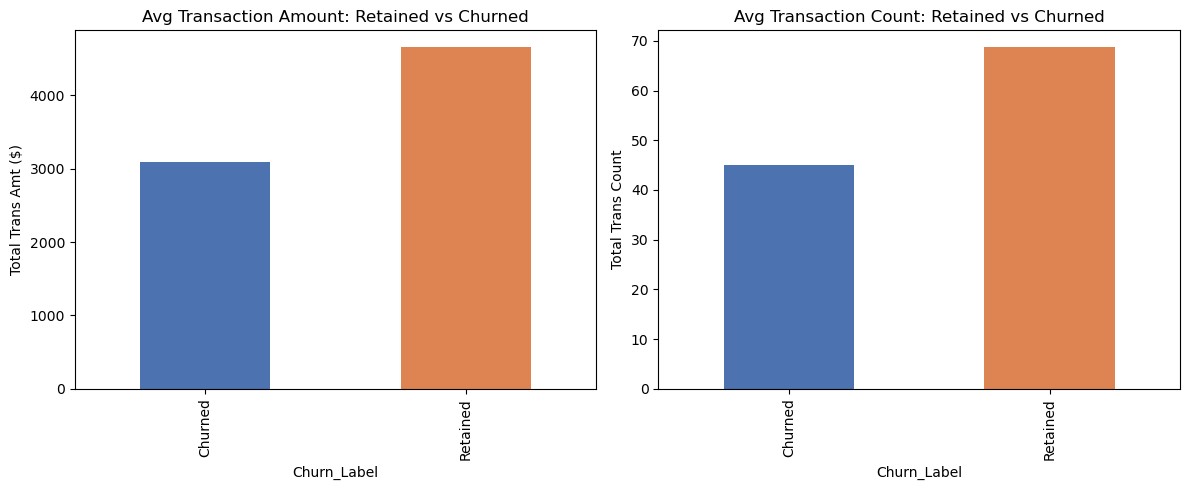

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('Churn_Label')['Total_Trans_Amt'].mean().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Avg Transaction Amount: Retained vs Churned')
axes[0].set_ylabel('Total Trans Amt ($)')

df.groupby('Churn_Label')['Total_Trans_Ct'].mean().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Avg Transaction Count: Retained vs Churned')
axes[1].set_ylabel('Total Trans Count')

plt.tight_layout()
plt.savefig('h1_engagement.png', dpi=150)
plt.show()

## 3. Hypothesis 2: Product Utilization

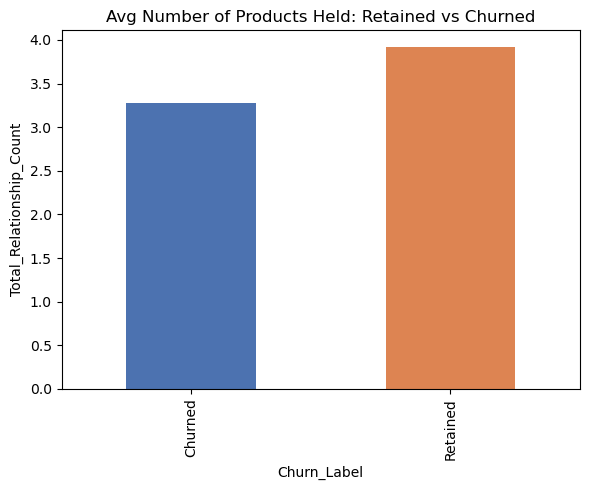

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
df.groupby('Churn_Label')['Total_Relationship_Count'].mean().plot(kind='bar', ax=ax, color=['#4C72B0', '#DD8452'])
ax.set_title('Avg Number of Products Held: Retained vs Churned')
ax.set_ylabel('Total_Relationship_Count')
plt.tight_layout()
plt.savefig('h2_product_util.png', dpi=150)
plt.show()

## 4. Hypothesis 3: Service Friction

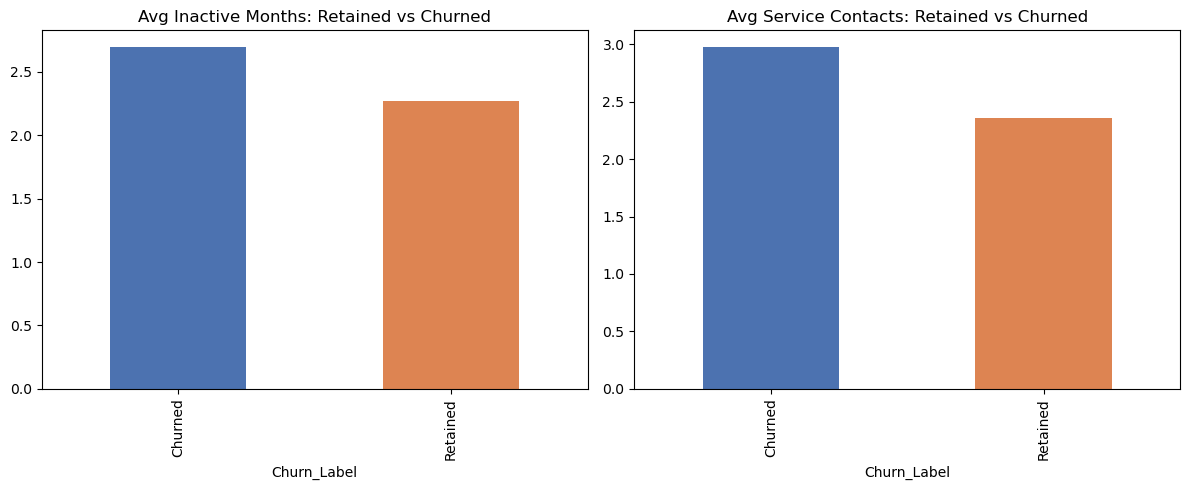

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.groupby('Churn_Label')['Months_Inactive_12_mon'].mean().plot(kind='bar', ax=axes[0], color=['#4C72B0', '#DD8452'])
axes[0].set_title('Avg Inactive Months: Retained vs Churned')

df.groupby('Churn_Label')['Contacts_Count_12_mon'].mean().plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('Avg Service Contacts: Retained vs Churned')

plt.tight_layout()
plt.savefig('h3_service_friction.png', dpi=150)
plt.show()

In [14]:
# Median splits for value (Credit_Limit) and churn risk
value_median = df['Credit_Limit'].median()
df['Value_Tier'] = df['Credit_Limit'].apply(lambda x: 'High Value' if x >= value_median else 'Low Value')

# Churn risk: since Churned is already binary, use it directly as risk indicator
df['Risk_Tier'] = df['Churned'].apply(lambda x: 'High Risk' if x == 1 else 'Low Risk')

# Build the 2x2 matrix - count of customers per quadrant
matrix = pd.crosstab(df['Value_Tier'], df['Risk_Tier'])
print(matrix)

# % of total value sitting in High Value / High Risk quadrant
total_value = df['Credit_Limit'].sum()
high_value_high_risk_value = df[(df['Value_Tier']=='High Value') & (df['Risk_Tier']=='High Risk')]['Credit_Limit'].sum()
pct_value_at_risk = (high_value_high_risk_value / total_value) * 100

print(f"\n% of total portfolio value in High Value / High Risk quadrant: {pct_value_at_risk:.1f}%")

Risk_Tier   High Risk  Low Risk
Value_Tier                     
High Value        757      4309
Low Value         870      4191

% of total portfolio value in High Value / High Risk quadrant: 12.7%


## 5. Segment Sizing (2x2 Matrix)

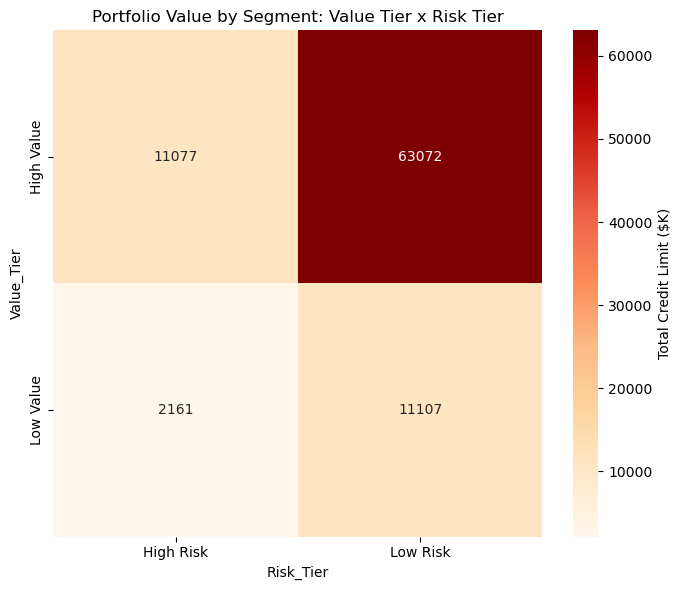

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

pivot = df.pivot_table(index='Value_Tier', columns='Risk_Tier', values='Credit_Limit', aggfunc='sum')
pivot = pivot / 1000  # convert to $K for readability

fig, ax = plt.subplots(figsize=(7,6))
sns.heatmap(pivot, annot=True, fmt='.0f', cmap='OrRd', cbar_kws={'label': 'Total Credit Limit ($K)'}, ax=ax)
ax.set_title('Portfolio Value by Segment: Value Tier x Risk Tier')
plt.tight_layout()
plt.savefig('segment_matrix.png', dpi=150)
plt.show()